# 01 - Data Generation and EDA <a id="top"></a>

This notebook is the entry point for the project.

It explains the synthetic manufacturing data story, generates the public CSV files, and performs a first exploratory data analysis pass before any machine learning is introduced.

The goal is not to build a full silicon photonics simulator.

The goal is to create a controlled synthetic dataset that behaves like a simplified wafer-level manufacturing problem:

- every die has inline metrology measurements
- only some dies have downstream optical test results
- tested dies can pass or fail a downstream specification
- wafer-level and local spatial effects can create visible patterns
- resonance wavelength is generated from a simple physical sensitivity model

The main EDA question is:

> Does the generated dataset behave like a coherent wafer-level manufacturing dataset rather than arbitrary random numbers?

## Contents

- [Plain-language glossary](#glossary)
- [How the synthetic dataset is generated](#data-generation)
- [What the two tables mean](#tables)
- [Downstream status counts](#status-counts)
- [Downstream target distributions and specification limits](#downstream-distributions)
- [Inline feature distributions](#inline-distributions)
- [Relationship between inline geometry measurements and resonance wavelength](#inline-resonance-relationship)
- [Coverage and failure by wafer radius](#radial-summary)
- [Optional statistical sanity check](#statistical-sanity-check)
- [Summary](#summary)

## Plain-language glossary <a id="glossary"></a>

Before looking at the data, we define the main terms used throughout the project.

- **Wafer**: one circular silicon slice that contains many repeated chip locations.
- **Die**: one chip location on the wafer.
- **Inline metrology**: measurements collected during or near fabrication. In this synthetic dataset, every die has inline metrology.
- **Downstream test**: later optical test data. It is more expensive, so only some dies are tested.
- **Microring resonator**: a small ring-shaped optical device whose resonance wavelength is sensitive to geometry.
- **`lambda_res_nm`**: measured resonance wavelength in nanometers. This is the main downstream regression target.
- **`q_loaded`**: loaded quality factor. Higher usually means lower optical loss.
- **`test_pass`**: downstream pass/fail flag. `1` means pass, `0` means fail.
- **Not tested**: a die with inline metrology but no downstream row.

Let's setup the necessary libraries, custom modules and set up the project structure.

In [ ]:
# Import standard libraries
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Set up project structure and paths
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
elif not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = Path("..").resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Datasets are generated and stored in the "data" directory at the project root
DATA_DIR = PROJECT_ROOT / "data"

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 40)

# Import custom modules
from src.generator import SyntheticMRRDataGenerator
from src.physics import SyntheticMRRProcessConfig
from src.utils import (
    merge_sources,
    plot_feature_distributions,
    plot_inline_vs_resonance,
    save_sources,
    validate_schemas,
)

## How the synthetic dataset is generated <a id="data-generation"></a>

The synthetic dataset is produced by `SyntheticMRRDataGenerator` in `src/generator.py`.

For the purpose of this notebook, the generator can be treated as a black box. We do not need to inspect every implementation detail here. What matters is the data-generating story behind it.

The important idea is that the inline and downstream tables are generated from the same hidden synthetic manufacturing state. This creates a meaningful relationship between early metrology measurements and later optical test results, while keeping the hidden true values out of the public modeling dataset.

The simplified flow is:

```text
wafer layout
        ↓
hidden synthetic manufacturing state
        ↓
noisy inline metrology measurements
        ↓
partial downstream optical testing
        ↓
pass/fail downstream labels
```

### Wafer layout

The generator starts by creating a simplified wafer layout.

Each wafer contains dies placed on a regular grid. The grid is clipped by a circular wafer footprint, so the final layout resembles a simplified wafer map.

Each die receives a physical position on the wafer through `x_mm`, `y_mm`, and `r_mm`.

The radial coordinate `r_mm` measures distance from the wafer center. It is useful later when we check whether edge dies behave differently from center dies.

### Hidden synthetic manufacturing state

Behind the public CSV files, the generator creates a hidden physical state for every die.

This hidden state represents the synthetic “true” condition of the die before measurement noise is added. It includes quantities such as true waveguide width, true silicon thickness, true roughness, true defectivity, true resonance wavelength, and true Q-factor.

These hidden values are not written into the public modeling dataset. This is intentional. In a real manufacturing setting, we do not get perfect access to the true physical state of each device. We only observe measurements.

### Inline metrology measurements

The measured inline columns are noisy observations of hidden true values.

For example, the true waveguide width of die $i$ is represented as $w_i$. The inline metrology tool does not observe $w_i$ perfectly. Instead, it records a measured value:

$$
w_{i,\mathrm{meas}} = w_i + \epsilon_{i,\mathrm{width}}
$$

Similarly, the true silicon thickness of die $i$ is represented as $t_i$. The measured thickness is:

$$
t_{i,\mathrm{meas}} = t_i + \epsilon_{i,\mathrm{thickness}}
$$

Here:

- $w_i$ is the hidden true waveguide width for die $i$
- $t_i$ is the hidden true silicon thickness for die $i$
- $w_{i,\mathrm{meas}}$ is the measured inline width
- $t_{i,\mathrm{meas}}$ is the measured inline thickness
- $\epsilon_{i,\mathrm{width}}$ is measurement noise in the width measurement
- $\epsilon_{i,\mathrm{thickness}}$ is measurement noise in the thickness measurement

The noise terms are not functions of width or thickness in this simplified notation. They represent measurement uncertainty added by the metrology process.

### Downstream optical testing

The downstream table is generated later in the synthetic flow. Only some dies receive downstream optical test results.

For tested dies, the generator creates measured optical outputs such as `lambda_res_nm`, `q_loaded`, `insertion_loss_db`, and `test_pass`.

The resonance wavelength is generated from the simplified first-order physical model:

$$
\lambda_i =
\lambda_0
+
\alpha (t_i - t_0)
+
\beta (w_i - w_0)
+
\eta_i^{(\lambda)}
$$

This means that small deviations in true silicon thickness and true waveguide width shift the resonance wavelength.

The noise term $\eta_i^{(\lambda)}$ represents downstream measurement noise and residual effects not explicitly modeled.

The loaded Q-factor is generated from a simple log-linear degradation model:

$$
\log Q_i =
\log Q_0
-
k_r r_i
-
k_d d_i
+
\eta_i^{(Q)}
$$

This means that higher roughness and higher defect density reduce optical quality.

### Downstream pass/fail rule

Finally, the generator applies a downstream specification rule.

A tested die passes only if its measured resonance wavelength is inside the allowed specification window:

$$
\lambda_{\mathrm{spec,min}}
\le
\lambda_{\mathrm{res,nm}}
\le
\lambda_{\mathrm{spec,max}}
$$

and its loaded Q is above the minimum acceptable value:

$$
q_{\mathrm{loaded}} \ge q_{\mathrm{spec,min}}
$$

Otherwise, the tested die fails.

### Public output tables

The final public output is two CSV files.

`synthetic_inline_metrology.csv` has one row per die and acts as the feature-side data source.

`synthetic_downstream_wafer_test.csv` has one row per tested die and acts as the target-side data source.

If a die has no downstream row, it is treated as not tested, not as failed.

The rest of this notebook checks whether these generated tables behave like a coherent synthetic manufacturing dataset.

In [ ]:

# Use a fixed seed so the synthetic dataset is reproducible.
SEED = 42

# These parameters hold the nominal design point, noise levels, and spec limits.
params = SyntheticMRRProcessConfig(
    # Small but visible lot-level process differences
    sigma_w_lot=0.25,
    sigma_t_lot=0.18,
    roughness_lot_std=0.04,
    defect_density_lot_std=0.08,

    # Reduced wafer-to-wafer drift
    sigma_w_wafer=0.45,
    sigma_t_wafer=0.35,
    roughness_std=0.10,
    defect_density_std=0.20,

    # Within-wafer spatial structure
    spatial_rms=0.25,
    spatial_field_scale=0.8,
    edge_failure_strength=1.8,
    edge_failure_center=0.72,
    edge_failure_width=0.08,
    ring_failure_strength=0.8,

    # Production-like downstream spec
    lambda_spec_min=1544.0,
    lambda_spec_max=1554.0,
    q_spec_min=135000.0,
)

gen = SyntheticMRRDataGenerator(params=params, seed=SEED)

# Generate the two public tables used by the rest of the project.
df_inline, df_downstream = gen.generate_dataset(
    n_wafers=30,
    n_dies_per_wafer=400,
    p_downstream_sample=0.50,
)

# Validate before saving so schema mistakes are caught early.
validate_schemas(df_inline, df_downstream)
save_sources(df_inline, df_downstream, output_dir=str(DATA_DIR), prefix="synthetic")

# Print a compact summary to sanity-check coverage, pass/fail mix, and ranges.
stats = gen.validate_and_summarize(df_inline, df_downstream)
print("Summary statistics:")
for key, value in stats.items():
    print(f"  {key}: {value}")

Saved inline metrology: e:\Data_Science_Proj\data\synthetic_inline_metrology.csv
Saved downstream wafer test: e:\Data_Science_Proj\data\synthetic_downstream_wafer_test.csv
Summary statistics:
  n_dies_inline: 12000
  n_dies_downstream: 5433
  n_dies_downstream_pass: 3930
  n_dies_downstream_fail: 1503
  n_dies_not_tested: 6567
  coverage_pct: 45.275
  n_wafers: 30
  n_lots: 5
  not_tested_pct: 54.725
  pass_rate_pct: 72.33572611816676
  lambda_min: 1547.3399888808594
  lambda_max: 1553.2089786539236
  lambda_mean: 1550.160616450685
  lambda_std: 0.9195348861003068
  q_min: 80950.94767878922
  q_max: 241102.8882960683
  q_mean: 148036.7887650538
  q_std: 20736.994940424327
  width_mean: 449.9427743321472
  width_std: 0.8201433236604617
  thickness_mean: 220.18001896951284
  thickness_std: 0.6547321136731781
  corr_width_lambda: 0.6402954198918703


### Dataset snapshot

The generated dataset contains 30 synthetic wafers and 12,000 dies in total. Every die has inline metrology, while only a subset has downstream optical test results.

| Metric | Value | Interpretation |
| --- | ---: | --- |
| Total inline dies | 12,000 | All generated dies |
| Downstream tested dies | 5,477 | Dies with optical test |
| Not tested dies | 6,523 | Inline only |
| Downstream coverage | 45.6% | Tested share |
| Not tested share | 54.4% | Missing downstream |
| Tested pass dies | 4,480 | Pass among tested |
| Tested fail dies | 997 | Fail among tested |
| Pass rate among tested | 81.8% | Production-like yield |
| Fail rate among tested | 18.2% | Non-trivial failures |
| Number of wafers | 30 | Wafer population |
| Number of lots | 5 | Lot groups |

The dataset has a realistic structure for this project: inline metrology is available for every die, but downstream optical testing is only partially available. Among tested dies, most devices pass, while a smaller but meaningful fraction fails.

## What the two tables mean <a id="tables"></a>

The generator writes two public CSV files.


### Inline metrology table

`synthetic_inline_metrology.csv`

This table has one row per die. It represents early measurements that are assumed to be cheaper and more available.

These measurements describe process and geometry-related quantities such as width, thickness, roughness proxy, overlay, and defect-density proxy.

### Inline metrology columns

The inline table contains one row per die. Some columns identify where the die is located, while others represent measured process or geometry quantities.

Identifier and spatial columns:

| Column | Meaning |
| --- | --- |
| `wafer_id` | Identifier of the wafer |
| `lot_id` | Identifier of the manufacturing lot |
| `die_id` | Identifier of the die on a wafer |
| `x_mm` | Die x-position on the wafer, in millimeters |
| `y_mm` | Die y-position on the wafer, in millimeters |
| `r_mm` | Distance from wafer center, in millimeters |

The spatial columns are useful because manufacturing variation is often not purely random. Dies near the wafer edge may behave differently from dies near the center.

Measured inline metrology columns:

| Column | Meaning |
| --- | --- |
| `wg_width_nm_meas` | Measured waveguide width, in nanometers |
| `soi_thickness_nm_meas` | Measured silicon layer thickness, in nanometers |
| `etch_depth_nm_meas` | Measured etch depth, in nanometers |
| `roughness_rms_nm_meas` | Measured roughness proxy, in nanometers RMS |
| `overlay_x_nm_meas` | Measured x-direction alignment error, in nanometers |
| `overlay_y_nm_meas` | Measured y-direction alignment error, in nanometers |
| `defect_density_cm2_meas` | Measured defect-density proxy, in defects per cm² (tied to silicon quality)|
| `metrology_valid` | Flag indicating whether inline metrology is usable |

In plain language, these columns describe what the fabrication process produced before optical testing happens.

For this project, the most important geometry-related inline features are `wg_width_nm_meas` and `soi_thickness_nm_meas`, because the simplified resonance model uses waveguide width and silicon thickness to generate resonance wavelength shifts.

The roughness and defect-density columns are more related to optical quality degradation, especially the loaded Q-factor. Overlay and etch-depth measurements are included as additional process-related features that make the inline table look more like a realistic metrology source.

In [ ]:
display(df_inline.head(10))

,wafer_id,lot_id,die_id,x_mm,y_mm,r_mm,wg_width_nm_meas,soi_thickness_nm_meas,etch_depth_nm_meas,roughness_rms_nm_meas,overlay_x_nm_meas,overlay_y_nm_meas,defect_density_cm2_meas,metrology_valid
0,W001,L01,D_R001_C008,-21.304348,-63.913043,67.370263,450.085492,221.265588,78.425980,2.436370,0.582978,1.501057,3288.488026,1
1,W001,L01,D_R001_C009,-15.217391,-63.913043,65.699666,449.917262,220.652576,77.737256,2.905980,0.717936,-3.135393,2611.311907,1
2,W001,L01,D_R001_C010,-9.130435,-63.913043,64.561923,450.237884,220.602384,82.101074,2.704712,-1.049406,-0.992895,1740.795828,1
3,W001,L01,D_R001_C011,-3.043478,-63.913043,63.985466,449.985126,219.686403,86.294707,2.480899,-1.394339,-0.000943,2989.078574,1
4,W001,L01,D_R001_C012,3.043478,-63.913043,63.985466,450.910552,221.187374,82.212604,2.618635,2.122632,-1.286136,2273.283045,1
5,W001,L01,D_R001_C013,9.130435,-63.913043,64.561923,450.592663,221.410641,91.400001,2.465357,-0.117672,1.895899,2480.282683,1
6,W001,L01,D_R001_C014,15.217391,-63.913043,65.699666,450.201658,220.321924,83.627874,2.916678,-2.158408,-1.035722,3264.381685,1
7,W001,L01,D_R001_C015,21.304348,-63.913043,67.370263,451.855830,219.896833,72.721646,2.765834,-1.534218,-0.707305,2211.160439,1
8,W001,L01,D_R002_C006,-33.478261,-57.826087,66.818039,450.075912,220.238197,89.908586,2.866144,1.762772,4.954129,2063.045299,1
9,W001,L01,D_R002_C007,-27.391304,-57.826087,63.985466,450.550246,220.084108,73.997451,2.720322,0.418731,-0.081092,2223.134967,1


### Downstream optical test table

`synthetic_downstream_wafer_test.csv`

This table has one row per die that was tested downstream.

A downstream row means that the die has a usable optical test result.

A die missing from the downstream table is not automatically a failed die. It is simply not tested downstream.

The three public downstream states are:

- `Pass`: downstream row exists and `test_pass = 1`
- `Fail`: downstream row exists and `test_pass = 0`
- `Not tested`: inline row exists, but no downstream row exists

### Downstream optical test columns

The downstream table contains measured optical outcomes for the subset of dies that were tested.

Identifier and test-context columns:

| Column | Meaning |
| --- | --- |
| `wafer_id` | Identifier of the wafer |
| `die_id` | Identifier of the die on a wafer |
| `test_station_id` | Identifier of the synthetic test station used for downstream testing |

The identifiers `wafer_id` and `die_id` are used to join downstream test results back to the inline metrology table.

The `test_station_id` column represents measurement context. In real test data, different tools or stations can introduce small measurement offsets. In this synthetic dataset, it makes the downstream table look closer to a real test source, but it should not be treated as a physical device property.

Measured downstream optical columns:

| Column | Meaning |
| --- | --- |
| `lambda_res_nm` | Measured resonance wavelength, in nanometers. This is the main regression target. |
| `q_loaded` | Measured loaded quality factor. Higher values usually indicate lower optical loss and a sharper resonance. |
| `insertion_loss_db` | Measured optical insertion loss, in decibels. Higher loss means less optical power reaches the output. |
| `test_pass` | Pass/fail result for the tested die. `1` means pass, `0` means fail. |

The most important downstream quantity in this project is `lambda_res_nm`.

It represents where the microring resonance actually appears after fabrication and downstream optical testing. The baseline ML model tries to predict this value from inline metrology measurements.

The `q_loaded` column is used as a quality-related downstream metric. It is not the main regression target in the baseline notebook, but it is important for the pass/fail rule. A device can fail even if its resonance wavelength is acceptable, if its Q-factor is too low.

The `insertion_loss_db` column provides another optical performance indicator. It is included to make the downstream table more realistic, but it is not the main focus of the baseline model.

The `test_pass` column is derived from the downstream specification rule. It should not be used as an input feature when predicting `lambda_res_nm`, because it is already a downstream outcome.

In [ ]:
display(df_downstream.head(10))

,wafer_id,die_id,test_station_id,lambda_res_nm,q_loaded,insertion_loss_db,test_pass
0,W013,D_R009_C021,TS2,1549.188865,142347.324467,5.044082,1
1,W024,D_R018_C020,TS2,1549.311243,151781.021171,5.038523,1
2,W026,D_R018_C005,TS3,1551.949406,129964.997412,5.045583,0
3,W030,D_R011_C017,TS2,1549.532582,175244.226093,5.020161,1
4,W022,D_R021_C009,TS3,1549.001325,119435.730185,5.044331,0
5,W018,D_R011_C009,TS2,1549.836601,160503.199951,5.018505,1
6,W030,D_R019_C005,TS2,1549.374198,147924.651458,5.033427,1
7,W009,D_R015_C020,TS2,1549.448229,148212.635548,5.031628,1
8,W017,D_R009_C010,TS2,1548.399207,153418.480164,5.018590,1
9,W028,D_R020_C004,TS3,1551.125137,125290.150002,5.049849,0


## Downstream status counts <a id="status-counts"></a>

Before looking at individual features, let's first check the basic downstream population.

This plot answers a simple question:

> Did the generator create a useful mix of pass, fail, and not-tested dies?

This matters because the project would be uninteresting if all dies passed, all dies failed, or all dies were tested.

A meaningful synthetic manufacturing dataset should contain:

- dies that pass downstream specification
- dies that fail downstream specification
- dies that were not tested downstream

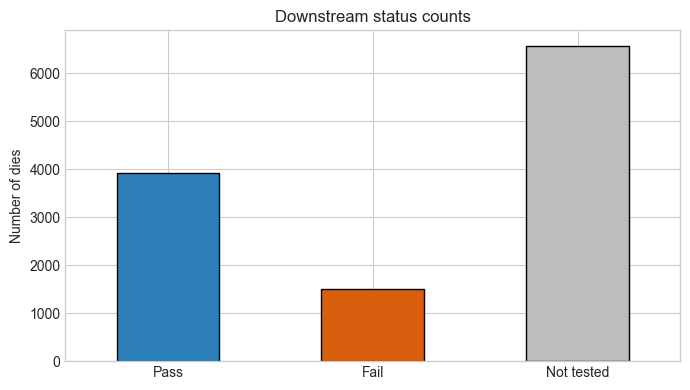

,die_count
Pass,3930
Fail,1503
Not tested,6567


In [ ]:
# A missing downstream row means "not tested", not "failed".
status_counts = pd.Series({
    'Pass': int((df_downstream['test_pass'] == 1).sum()),
    'Fail': int((df_downstream['test_pass'] == 0).sum()),
    'Not tested': int(len(df_inline) - len(df_downstream)),
})

# Plot the three states as the first high-level health check of the dataset.
fig, ax = plt.subplots(figsize=(7, 4))
status_counts.plot(kind='bar', ax=ax, color=['#2C7FB8', '#D95F0E', '#BDBDBD'], edgecolor='black')
ax.set_title('Downstream status counts')
ax.set_ylabel('Number of dies')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

status_counts.to_frame('die_count')

The not-tested group exists because downstream optical testing is assumed to be more expensive and only partially available.

The pass/fail split exists because the generator applies a downstream specification rule based on resonance wavelength and loaded Q.

## Downstream target distributions and specification limits <a id="downstream-distributions"></a>

The downstream table contains the measured optical quantities used by the pass/fail rule.

A tested die passes only if its resonance wavelength falls inside the allowed wavelength window:

$$
\lambda_{\mathrm{spec,min}}
\le
\lambda_{\mathrm{res,nm}}
\le
\lambda_{\mathrm{spec,max}}
$$

**and** its loaded Q is above the minimum Q threshold:

$$
q_{\mathrm{loaded}} \ge q_{\mathrm{spec,min}}
$$

The histograms below show how tested dies are distributed relative to these specification limits.

This plot answers:

> Is the downstream pass/fail problem meaningful?

We expect most values to be near the nominal target, but some tested dies should fall outside the allowed wavelength window or below the minimum Q threshold.

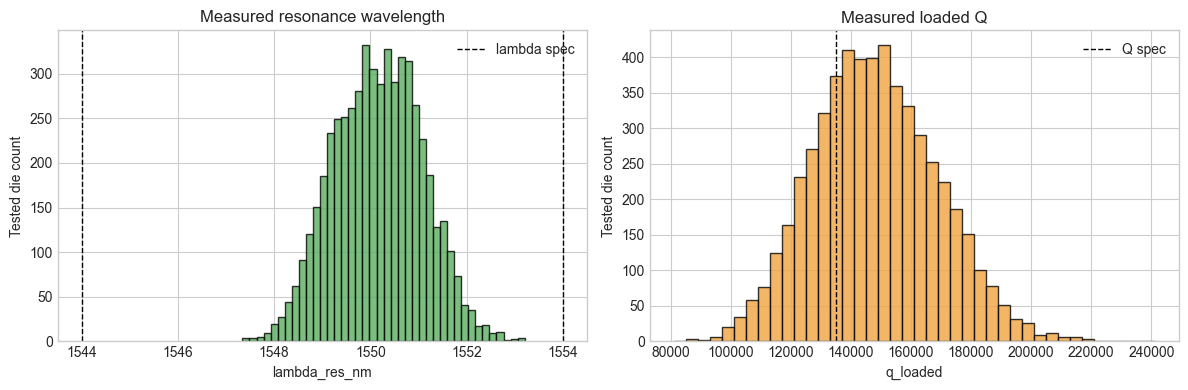

In [ ]:
# Compare measured downstream values with the spec thresholds used by test_pass.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(
    df_downstream["lambda_res_nm"],
    bins=40,
    color="#5AAE61",
    edgecolor="black",
    alpha=0.8,
)
# The two dashed lines mark the allowed resonance window.
axes[0].axvline(
    params.lambda_spec_min,
    color="black",
    linestyle="--",
    linewidth=1,
    label="lambda spec",
)
axes[0].axvline(
    params.lambda_spec_max,
    color="black",
    linestyle="--",
    linewidth=1,
)
axes[0].set_title("Measured resonance wavelength")
axes[0].set_xlabel("lambda_res_nm")
axes[0].set_ylabel("Tested die count")
axes[0].legend()

axes[1].hist(
    df_downstream["q_loaded"],
    bins=40,
    color="#F1A340",
    edgecolor="black",
    alpha=0.8,
)
# The dashed line marks the minimum acceptable loaded Q.
axes[1].axvline(
    params.q_spec_min,
    color="black",
    linestyle="--",
    linewidth=1,
    label="Q spec",
)
axes[1].set_title("Measured loaded Q")
axes[1].set_xlabel("q_loaded")
axes[1].set_ylabel("Tested die count")
axes[1].legend()

plt.tight_layout()
plt.show()

The resonance wavelength histogram shows how much the optical response shifts across tested dies. The Q histogram shows whether some devices have degraded optical quality. 

## Inline feature distributions <a id="inline-distributions"></a>

Now we inspect the input side of the problem: the inline metrology measurements.

These histograms are a sanity check.

They do not prove that the data is real or physically complete. Instead, they check whether the generated measurements have reasonable ranges and smooth process-like variation.

For geometry-related features such as waveguide width and silicon thickness, we expect values to cluster around nominal process values.

For positive quality-related quantities such as roughness and defect-density proxy, some skew is acceptable.

This section answers:

> Do the generated inline measurements look controlled and process-like, rather than broken or arbitrary?

Things to look for:

- reasonable value ranges
- no impossible negative geometry values
- smooth variation around nominal values
- no obvious broken distributions
- different feature types having different distribution shapes

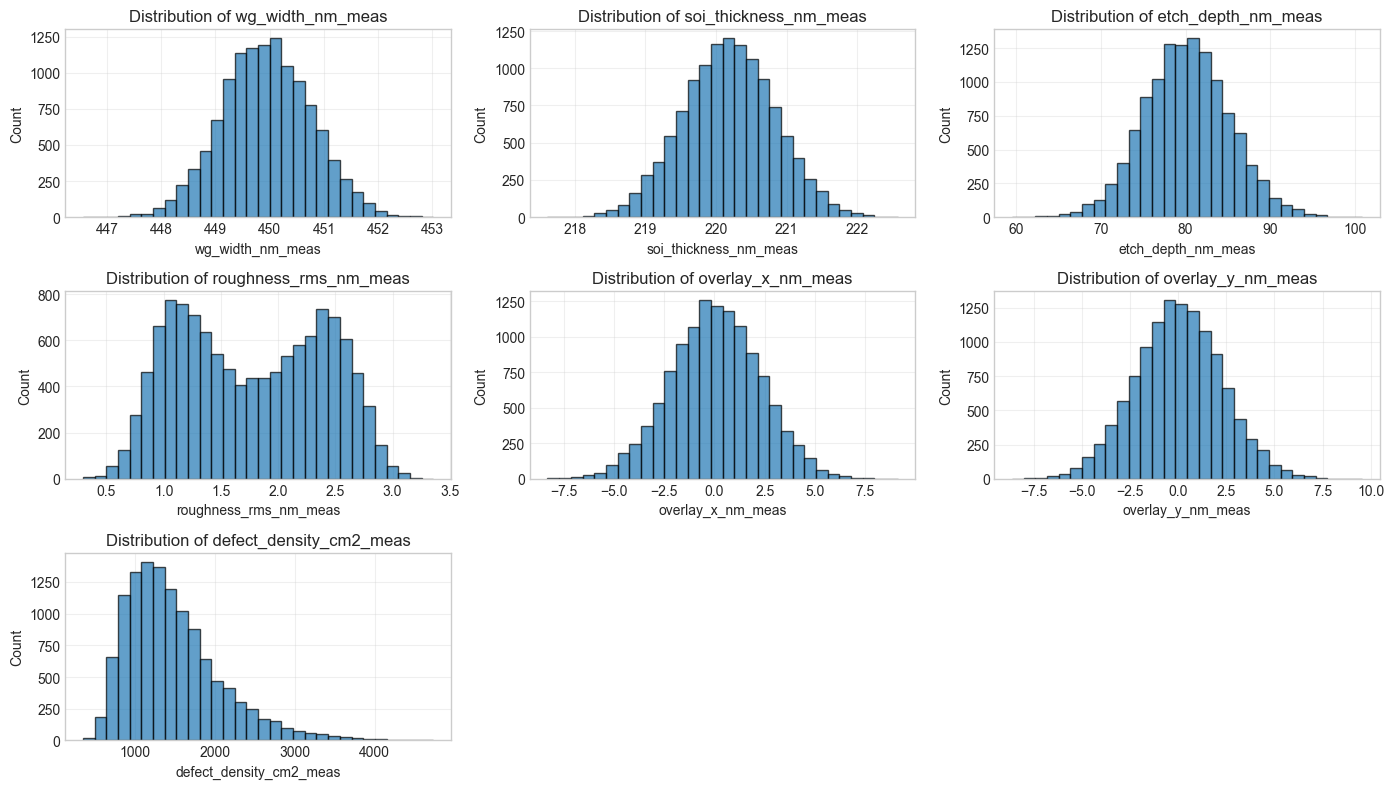

In [ ]:
plot_feature_distributions(df_inline, figsize=(14, 8))

## Relationship between inline geometry measurements and resonance wavelength <a id="inline-resonance-relationship"></a>

The physical model used by the generator says that resonance wavelength ($\lambda_i$) should mainly depend on waveguide width ($w_i$) and silicon thickness ($t_i$).

This section checks whether that relationship is visible in the public observed data.

First, we merge the inline and downstream tables. We keep only tested dies, because `lambda_res_nm` exists only for dies with downstream optical test results.

Then we use a scatter plot as a visual check. If the synthetic physical story is visible, dies with larger measured width or thickness deviations should generally show larger resonance shifts.

Finally, we compute Pearson correlations between each inline feature and `lambda_res_nm`.

Pearson correlation measures the strength of a linear relationship between two variables:

$$
r_{x,y}
=
\frac{
\sum_i (x_i - \bar{x})(y_i - \bar{y})
}{
\sqrt{
\sum_i (x_i - \bar{x})^2
}
\sqrt{
\sum_i (y_i - \bar{y})^2
}
}
$$

We expect `wg_width_nm_meas` and `soi_thickness_nm_meas` to have the strongest positive correlations with `lambda_res_nm`, because they are the measured versions of the geometry terms used in the first-order resonance model.

Each dot represents a die, with color depending on the specific wafer. The colored bands show that wafers can have different systematic offsets, while the overall upward trend shows that larger measured waveguide width generally corresponds to a larger downstream resonance shift. The dashed red line is a simple linear fit across all tested dies.

The plot uses deviations from nominal values rather than absolute values.

The x-axis is:

$$
w_{\mathrm{meas}} - w_0
$$

and the y-axis is:

$$
\lambda_{\mathrm{res}} - \lambda_0
$$

This matches the first-order physical model, which describes resonance shift as a function of geometry deviations around a nominal design point.

A positive x-value means the measured waveguide is wider than nominal. A positive y-value means the measured resonance wavelength is above the nominal wavelength.

Merged tested rows: 5433


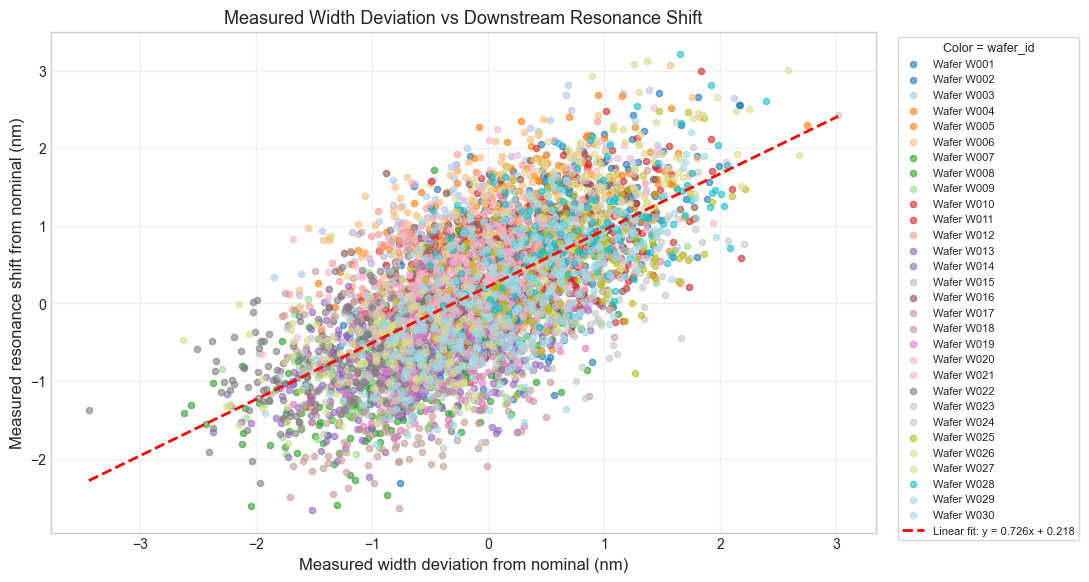

,corr_with_lambda_res_nm
wg_width_nm_meas,0.640295
soi_thickness_nm_meas,0.406003
defect_density_cm2_meas,0.091644
roughness_rms_nm_meas,0.044627
etch_depth_nm_meas,0.032467
overlay_y_nm_meas,0.017203
overlay_x_nm_meas,0.011560


In [ ]:
# Inner join keeps only dies that have both inline measurements and downstream targets.
df_tested = merge_sources(df_inline, df_downstream, how="inner")
print(f"Merged tested rows: {len(df_tested)}")

plot_inline_vs_resonance(df_tested)

# Only public inline measurements are used in this EDA check.
feature_cols = [
    "wg_width_nm_meas",
    "soi_thickness_nm_meas",
    "etch_depth_nm_meas",
    "roughness_rms_nm_meas",
    "overlay_x_nm_meas",
    "overlay_y_nm_meas",
    "defect_density_cm2_meas",
]

# Correlation is not a model; it is a quick signal-strength sanity check.
corr = (
    df_tested[feature_cols + ["lambda_res_nm"]]
    .corr(numeric_only=True)["lambda_res_nm"]
    .drop("lambda_res_nm")
)
corr = corr.reindex(corr.abs().sort_values(ascending=False).index)

display(corr.to_frame("corr_with_lambda_res_nm"))

The correlation table acts as a numerical sanity check.

If `wg_width_nm_meas` and `soi_thickness_nm_meas` appear near the top, the observed data is consistent with the intended physical story: geometry-related inline measurements contain signal about downstream resonance wavelength.

Other features may still matter for quality or pass/fail behavior, but they are not expected to be the primary drivers of `lambda_res_nm`.

## Coverage and failure by wafer radius <a id="radial-summary"></a>

Before drawing full wafer maps, we first summarize the spatial behavior using distance from wafer center.

Each die has a radial coordinate `r_mm`, which measures how far the die is from the wafer center. We group dies into four radial regions: center, mid-inner, mid-outer, and edge. The radial bins are quantile-based. This means each bin contains roughly the same number of dies, ordered from smallest to largest distance from the wafer center.

For each region, we calculate two rates.

The first is downstream coverage:

$$
\mathrm{coverage\ rate}
=
\frac{\mathrm{number\ of\ tested\ dies}}
{\mathrm{number\ of\ inline\ dies}}
$$

This tells us what fraction of dies in that radial region have downstream optical test results.

The second is fail rate among tested dies:

$$
\mathrm{fail\ rate}
=
\frac{\mathrm{number\ of\ failed\ tested\ dies}}
{\mathrm{number\ of\ tested\ dies}}
$$

This tells us how often tested dies fail in that radial region.

This summary checks whether downstream behavior changes from wafer center to wafer edge. If the synthetic spatial effects are visible, edge dies should show worse downstream behavior than center dies.

,die_count,tested_count,fail_count,coverage_rate,fail_rate_among_tested
radius_bin,,,,,
center,3060,1471,78,0.480719,0.053025
mid-inner,2940,1363,181,0.463605,0.132795
mid-outer,3000,1331,506,0.443667,0.380165
edge,3000,1268,738,0.422667,0.582019


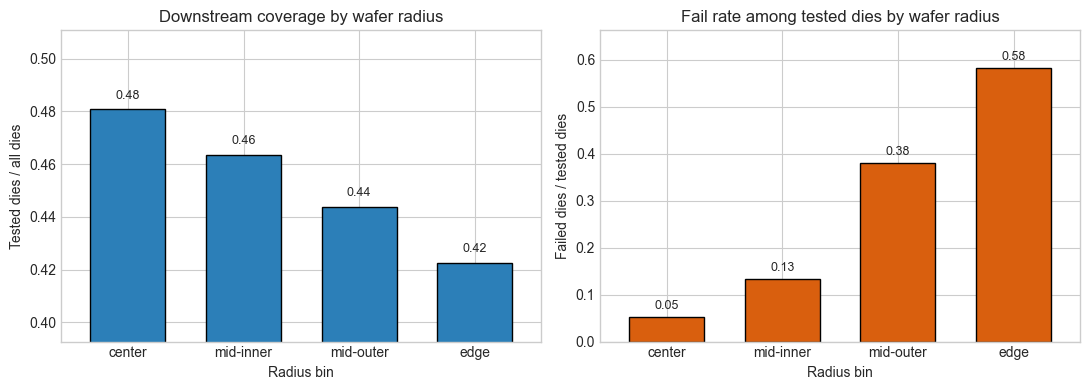

In [ ]:
df_status = df_inline.merge(
    df_downstream[["wafer_id", "die_id", "test_pass"]],
    on=["wafer_id", "die_id"],
    how="left",
)

df_status["tested_downstream"] = df_status["test_pass"].notna()
df_status["failed_downstream"] = df_status["test_pass"].eq(0)

df_status["radius_bin"] = pd.qcut(
    df_status["r_mm"],
    q=4,
    labels=["center", "mid-inner", "mid-outer", "edge"],
)

radius_summary = (
    df_status.groupby("radius_bin", observed=True)
    .agg(
        die_count=("die_id", "size"),
        tested_count=("tested_downstream", "sum"),
        fail_count=("failed_downstream", "sum"),
    )
)

radius_summary["coverage_rate"] = (
    radius_summary["tested_count"] / radius_summary["die_count"]
)

radius_summary["fail_rate_among_tested"] = (
    radius_summary["fail_count"] / radius_summary["tested_count"]
)

display(radius_summary)

plot_df = radius_summary.rename(
    columns={
        "coverage_rate": "Tested / all dies",
        "fail_rate_among_tested": "Failed / tested dies",
    }
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))


# Plot 1: downstream coverage
# This shows what fraction of all dies in each radial bin
# actually received a downstream optical test result.
coverage_values = plot_df["Tested / all dies"]

coverage_values.plot(
    kind="bar",
    ax=axes[0],
    color="#2C7FB8",
    edgecolor="black",
    width=0.65,
)

axes[0].set_title("Downstream coverage by wafer radius")
axes[0].set_ylabel("Tested dies / all dies")
axes[0].set_xlabel("Radius bin")
axes[0].tick_params(axis="x", rotation=0)

# Use a narrowed y-axis because coverage changes only mildly.
# This makes the center-to-edge trend visible.
axes[0].set_ylim(
    max(0, coverage_values.min() - 0.03),
    min(1, coverage_values.max() + 0.03),
)

for idx, value in enumerate(coverage_values):
    axes[0].text(
        idx,
        value + 0.003,
        f"{value:.2f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

# Plot 2: fail rate among tested dies
# This shows what fraction of tested dies failed in each radial bin.
fail_values = plot_df["Failed / tested dies"]

fail_values.plot(
    kind="bar",
    ax=axes[1],
    color="#D95F0E",
    edgecolor="black",
    width=0.65,
)

axes[1].set_title("Fail rate among tested dies by wafer radius")
axes[1].set_ylabel("Failed dies / tested dies")
axes[1].set_xlabel("Radius bin")
axes[1].tick_params(axis="x", rotation=0)
axes[1].set_ylim(0, min(1, fail_values.max() + 0.08))

for idx, value in enumerate(fail_values):
    axes[1].text(
        idx,
        value + 0.01,
        f"{value:.2f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

plt.tight_layout()
plt.show()

The coverage trend is mild but visible: edge dies are somewhat less likely to have downstream test results than center dies.

The failure trend is much stronger: among dies that were tested, the fail rate increases sharply from center to edge.

This suggests that the edge region has two related effects in the synthetic data: slightly reduced downstream coverage and substantially worse downstream pass/fail behavior among tested dies.

In other words, the edge does not only affect whether a die is tested; it also affects the quality of the dies that are tested.

This prepares us for the next notebook, where the same spatial behavior is shown directly as wafer maps.

## Optional statistical sanity check <a id="statistical-sanity-check"></a>

The previous section suggests that downstream status changes with wafer radius.

As a small hypothesis-testing example, we test whether downstream status is independent of radial wafer region.

We define downstream status as:

- `Pass`: the die has a downstream row and `test_pass = 1`
- `Fail`: the die has a downstream row and `test_pass = 0`
- `Not tested`: the die has no downstream row

The hypotheses are:

$$
H_0: \text{Downstream status is independent of radial region}
$$

$$
H_1: \text{Downstream status depends on radial region}
$$

We use a chi-square test of independence.

The chi-square test of independence is appropriate here because both variables are categorical.

The first categorical variable is the radial wafer region:

$$
\mathrm{radius\_bin}
\in
\{\mathrm{center}, \mathrm{mid\text{-}inner}, \mathrm{mid\text{-}outer}, \mathrm{edge}\}
$$

The second categorical variable is downstream status:

$$
\mathrm{downstream\_status}
\in
\{\mathrm{Pass}, \mathrm{Fail}, \mathrm{Not\ tested}\}
$$

The test compares the observed contingency table with the table we would expect if downstream status were independent of radial region.

For each cell in the contingency table, the expected count under independence is:

$$
E_{ij}
=
\frac{
(\mathrm{row\ total})_i
\cdot
(\mathrm{column\ total})_j
}{
\mathrm{grand\ total}
}
$$

where:

- $i$ indexes the radial region
- $j$ indexes the downstream status category
- $E_{ij}$ is the expected count in cell $(i,j)$ under independence

The chi-square statistic is:

$$
\chi^2
=
\sum_{i,j}
\frac{
(O_{ij} - E_{ij})^2
}{
E_{ij}
}
$$

where:

- $O_{ij}$ is the observed count in cell $(i,j)$
- $E_{ij}$ is the expected count in cell $(i,j)$

A small p-value suggests that the observed downstream status distribution differs across radial regions more than we would expect if the two variables were independent.

Geometrically, the p-value is the right-tail area of the chi-square distribution:

$$
p
=
P\left(
\chi^2_{\mathrm{df}=6}
\ge
\chi^2_{\mathrm{observed}}
\right)
$$

In this case, the degrees of freedom are:

$$
\mathrm{df}
=
(r - 1)(c - 1)
=
(4 - 1)(3 - 1)
=
6
$$

where $r$ is the number of radial regions and $c$ is the number of downstream status categories.

Because the dataset is relatively large, a very small p-value can occur even when the practical effect is not very strong. For that reason, we also report Cramer's V as an effect-size measure:

$$
V
=
\sqrt{
\frac{
\chi^2
}{
n \cdot \min(r - 1, c - 1)
}
}
$$

where:

- $n$ is the total number of observations
- $r$ is the number of rows in the contingency table
- $c$ is the number of columns in the contingency table

The p-value tells us whether the association is statistically visible.

Cramer's V tells us how strong the association is.

In [ ]:
from scipy.stats import chi2_contingency
import numpy as np

df_hyp = df_status.copy()

# Map the nullable test_pass column to the three public downstream states.
df_hyp["downstream_status"] = np.select(
    [
        df_hyp["test_pass"].eq(1),
        df_hyp["test_pass"].eq(0),
        df_hyp["test_pass"].isna(),
    ],
    [
        "Pass",
        "Fail",
        "Not tested",
    ],
    default="Unknown",
)

status_order = ["Pass", "Fail", "Not tested"]
radius_order = ["center", "mid-inner", "mid-outer", "edge"]

# The contingency table counts each status inside each radial region.
contingency = pd.crosstab(
    df_hyp["radius_bin"],
    df_hyp["downstream_status"],
).reindex(index=radius_order, columns=status_order)

print("Contingency table:")
display(contingency)

# Chi-square tests whether radius bin and downstream status look independent.
chi2_stat, p_value, dof, expected = chi2_contingency(contingency)

n = contingency.to_numpy().sum()
n_rows, n_cols = contingency.shape
# Cramer's V gives effect size, so we do not rely only on the p-value.
cramers_v = np.sqrt(chi2_stat / (n * min(n_rows - 1, n_cols - 1)))

print(f"Chi-square statistic: {chi2_stat:.4f}")
print(f"Degrees of freedom: {dof}")
print(f"P-value: {p_value:.4g}")
print(f"Cramer's V: {cramers_v:.4f}")

Contingency table:


downstream_status,Pass,Fail,Not tested
radius_bin,,,
center,1393,78,1589
mid-inner,1182,181,1577
mid-outer,825,506,1669
edge,530,738,1732


Chi-square statistic: 1179.1145
Degrees of freedom: 6
P-value: 1.585e-251
Cramer's V: 0.2217


The p-value is very small, so we reject the independence hypothesis. This suggests that downstream status is not uniformly distributed across radial wafer regions.

However, Cramer's V is small. This means the relationship is statistically visible but weak.

In practical terms, wafer radius contributes to the downstream status pattern, but it does not determine the status by itself. This is consistent with the synthetic generator: edge-related degradation creates a spatial signal, while geometry variation, Q degradation, sampling, and measurement noise also influence the final downstream outcome.

## Summary <a id="summary"></a>

This notebook generated and inspected the synthetic manufacturing dataset.

The main findings are:

- the generator creates two public tables: inline metrology and downstream optical test results
- every die has inline metrology, but only some dies have downstream test results
- the downstream population contains a useful mix of pass, fail, and not-tested dies
- inline geometry measurements have smooth, process-like distributions
- measured width and measured silicon thickness are the strongest features associated with resonance wavelength
- downstream behavior changes with wafer radius: edge regions show lower coverage and higher failure rates
- the chi-square sanity check suggests that downstream status is not independent of radial region, although the effect size is weak

The next notebook focuses on wafer maps, where the same spatial behavior is visualized directly.